# Анализ эмоционального окраса высказываний при помощи модели BERT

Разберём классический код, который приводят во всех учебниках. Попробуем дообучить модель BERT для распознавания эмоционального окраса из набора отзывов google Play, будем использовать библиотеку трансформеров Hugging Face.

- [Read the tutorial](https://www.curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/)
- [Read the `Getting Things Done with Pytorch` book](https://github.com/curiousily/Getting-Things-Done-with-Pytorch)

Для начала подключим графический процессор:

In [161]:
!nvidia-smi

Sun Dec 10 18:29:00 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   77C    P0    35W /  70W |   7075MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## BERT: основные идеи

Модель BERT была представлена в 2019 году в статье [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)). 

Основные идеи:

- Bidirectional (двунаправленность): для лучшего понимания текста нам необходимо посмотреть сначала в одну сторону (на предыдущее слово), потом в другую сторону (на последующее слово.)
- Transformers (трансформеры): модель была презентована в 2017 году в статье  [Attention Is All You Need](https://arxiv.org/abs/1706.03762). Трнасформеры умеют воспринимать всю последовательность токенов вместе, благодаря структуре и механизму внимания, в отличие, например от LSTM-модели, которая обрабатываает данные сначала слева направо, потом справа налево. Отличительной особенностью трансформеров является то, что они умеют воспринимать взаимосвязи между словами, например понимать, что 'him' связано с мужским именем Jim. 
- (Pre-trained) contextualized word embeddings - [Статья Deep contextualized word representations, представляющая модель ELMO](https://arxiv.org/abs/1802.05365v2) предлагает подход, как можно кодировать слова с учётом их значений и окружающего контекста. Вспоминаем пример "table" как стол и "table" как таблица. 

BERT изначально натренирован с максированным 15% токенов с целью научиться понять, что ставить вместо них.  Рассмотрим на примере

### Masked Language Modeling (Masked LM)

Задача заключается в том, чтобы предсказать замаксированные токены:

That's `[mask]` she `[mask]` -> That's what she said

### Next Sentence Prediction (NSP)

Даны два предложения. Задача заключается в том, чтобы понять, будет ли второе следовать за первым (бинарная классификация):

*Input* = `[CLS]` That's `[mask]` she `[mask]`. [SEP] Hahaha, nice! [SEP]

*Label* = *IsNext*

*Input* = `[CLS]` That's `[mask]` she `[mask]`. [SEP] Dwight, you ignorant `[mask]`! [SEP]

*Label* = *NotNext*

Корпус для тренировочного множества состоит из двух частей: [Toronto Book Corpus](https://arxiv.org/abs/1506.06724) (800M words) и English Wikipedia (2,500M words). В то время как оригинальная реализация трансформера подразумевает наличие энкодера (для чтения входных значений) и декодера (который делает предсказания), BERT использует только декодер.

BERT - это просто последовательность предобученных блоков энкодера классического трансформера. Существуют две верии - с 12 энкодерами (BERT base) и 24 энкодерами (BERT Large).

### Практическая реализация

Статья про BERT вышла сразу с [реализованным кодом](https://github.com/google-research/bert) и предобученными моделями.

Используя идеи Transfer Learning можно решать многие NLP задачи - классификацию, ответы на вопросы, анализ тональности текста и т.д. При помощи небольшого количества данных и недолгом дообучении можно получать неплохие результаты.

## Шаг 1. Установка библиотек

Будем пользоваться [the Transformers library](https://huggingface.co/transformers/) от Hugging Face:

In [162]:
!pip install -q -U watermark

In [163]:
!pip install -qq transformers

In [164]:
%reload_ext watermark
%watermark -v -p numpy,pandas,torch,transformers

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

numpy       : 1.23.5
pandas      : 1.5.3
torch       : 2.1.0+cu118
transformers: 4.35.2



In [3]:
#@title Setup & Config
import transformers
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
import torch

import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(##WRITE YOUR CODE HERE)
torch.manual_seed(##WRITE YOUR CODE HERE)

device = ##WRITE YOUR CODE HERE("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Шаг 2. Загрузка данных

Можно скачать по ссылке или использовать те, что прислала.

In [166]:
# !wget 1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV
# !wget 1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv

In [9]:
df = ##WRITE YOUR CODE HERE("reviews.csv")
df.head()

ModuleNotFoundError: No module named 'clear_ouput'

In [168]:
df.shape

(12495, 12)

Посмотрим, есть ли пропуски:

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12495 non-null  object
 1   userName              12495 non-null  object
 2   userImage             12495 non-null  object
 3   content               12495 non-null  object
 4   score                 12495 non-null  int64 
 5   thumbsUpCount         12495 non-null  int64 
 6   reviewCreatedVersion  10333 non-null  object
 7   at                    12495 non-null  object
 8   replyContent          5818 non-null   object
 9   repliedAt             5818 non-null   object
 10  sortOrder             12495 non-null  object
 11  appId                 12495 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.1+ MB


Посмотрим, сбалансированы ли классы:

Text(0.5, 0, 'review score')

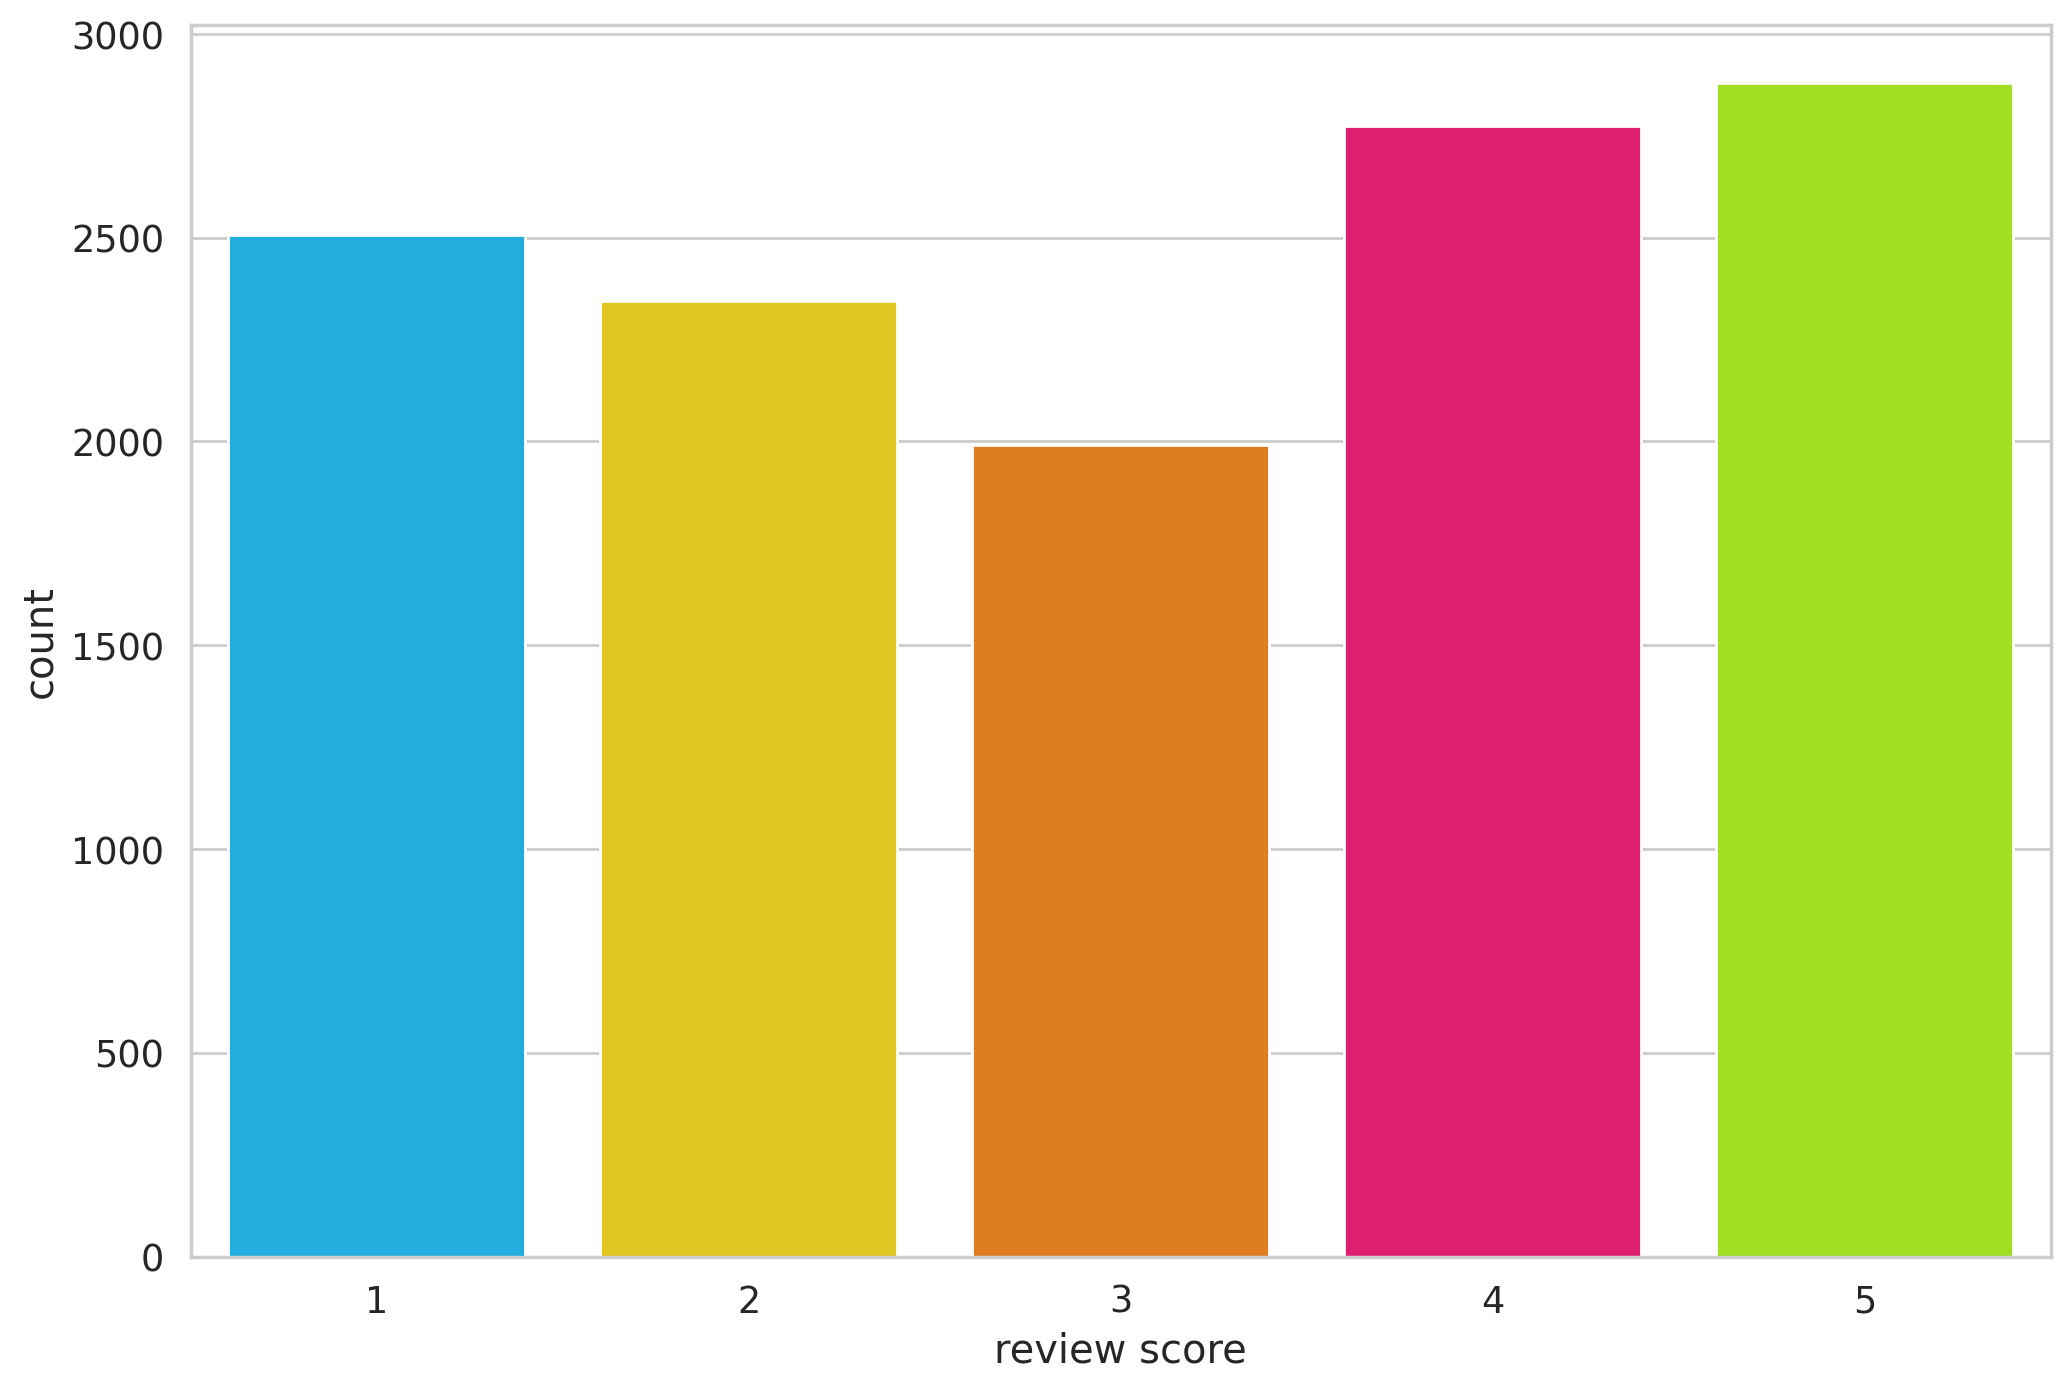

In [170]:
sns.countplot(df, x="score")
plt.xlabel('review score')

Немного разбалансированы, но для нашей задачи подойдёт. Попробуем перевести данные в классы: negative (рейтинг равен 1 или 2), neutral (рейтинг равен 3) и positive (рейтинг равен 4 или 5).

In [171]:
def to_sentiment(rating):
    rating = int(rating)
    ##WRITE YOUR CODE HERE

df['sentiment'] = df.score.apply(to_sentiment)

In [172]:
class_names = ['negative', ##WRITE YOUR CODE HERE, 'positive']

[Text(0, 0, 'negative'), Text(1, 0, 'neutral'), Text(2, 0, 'positive')]

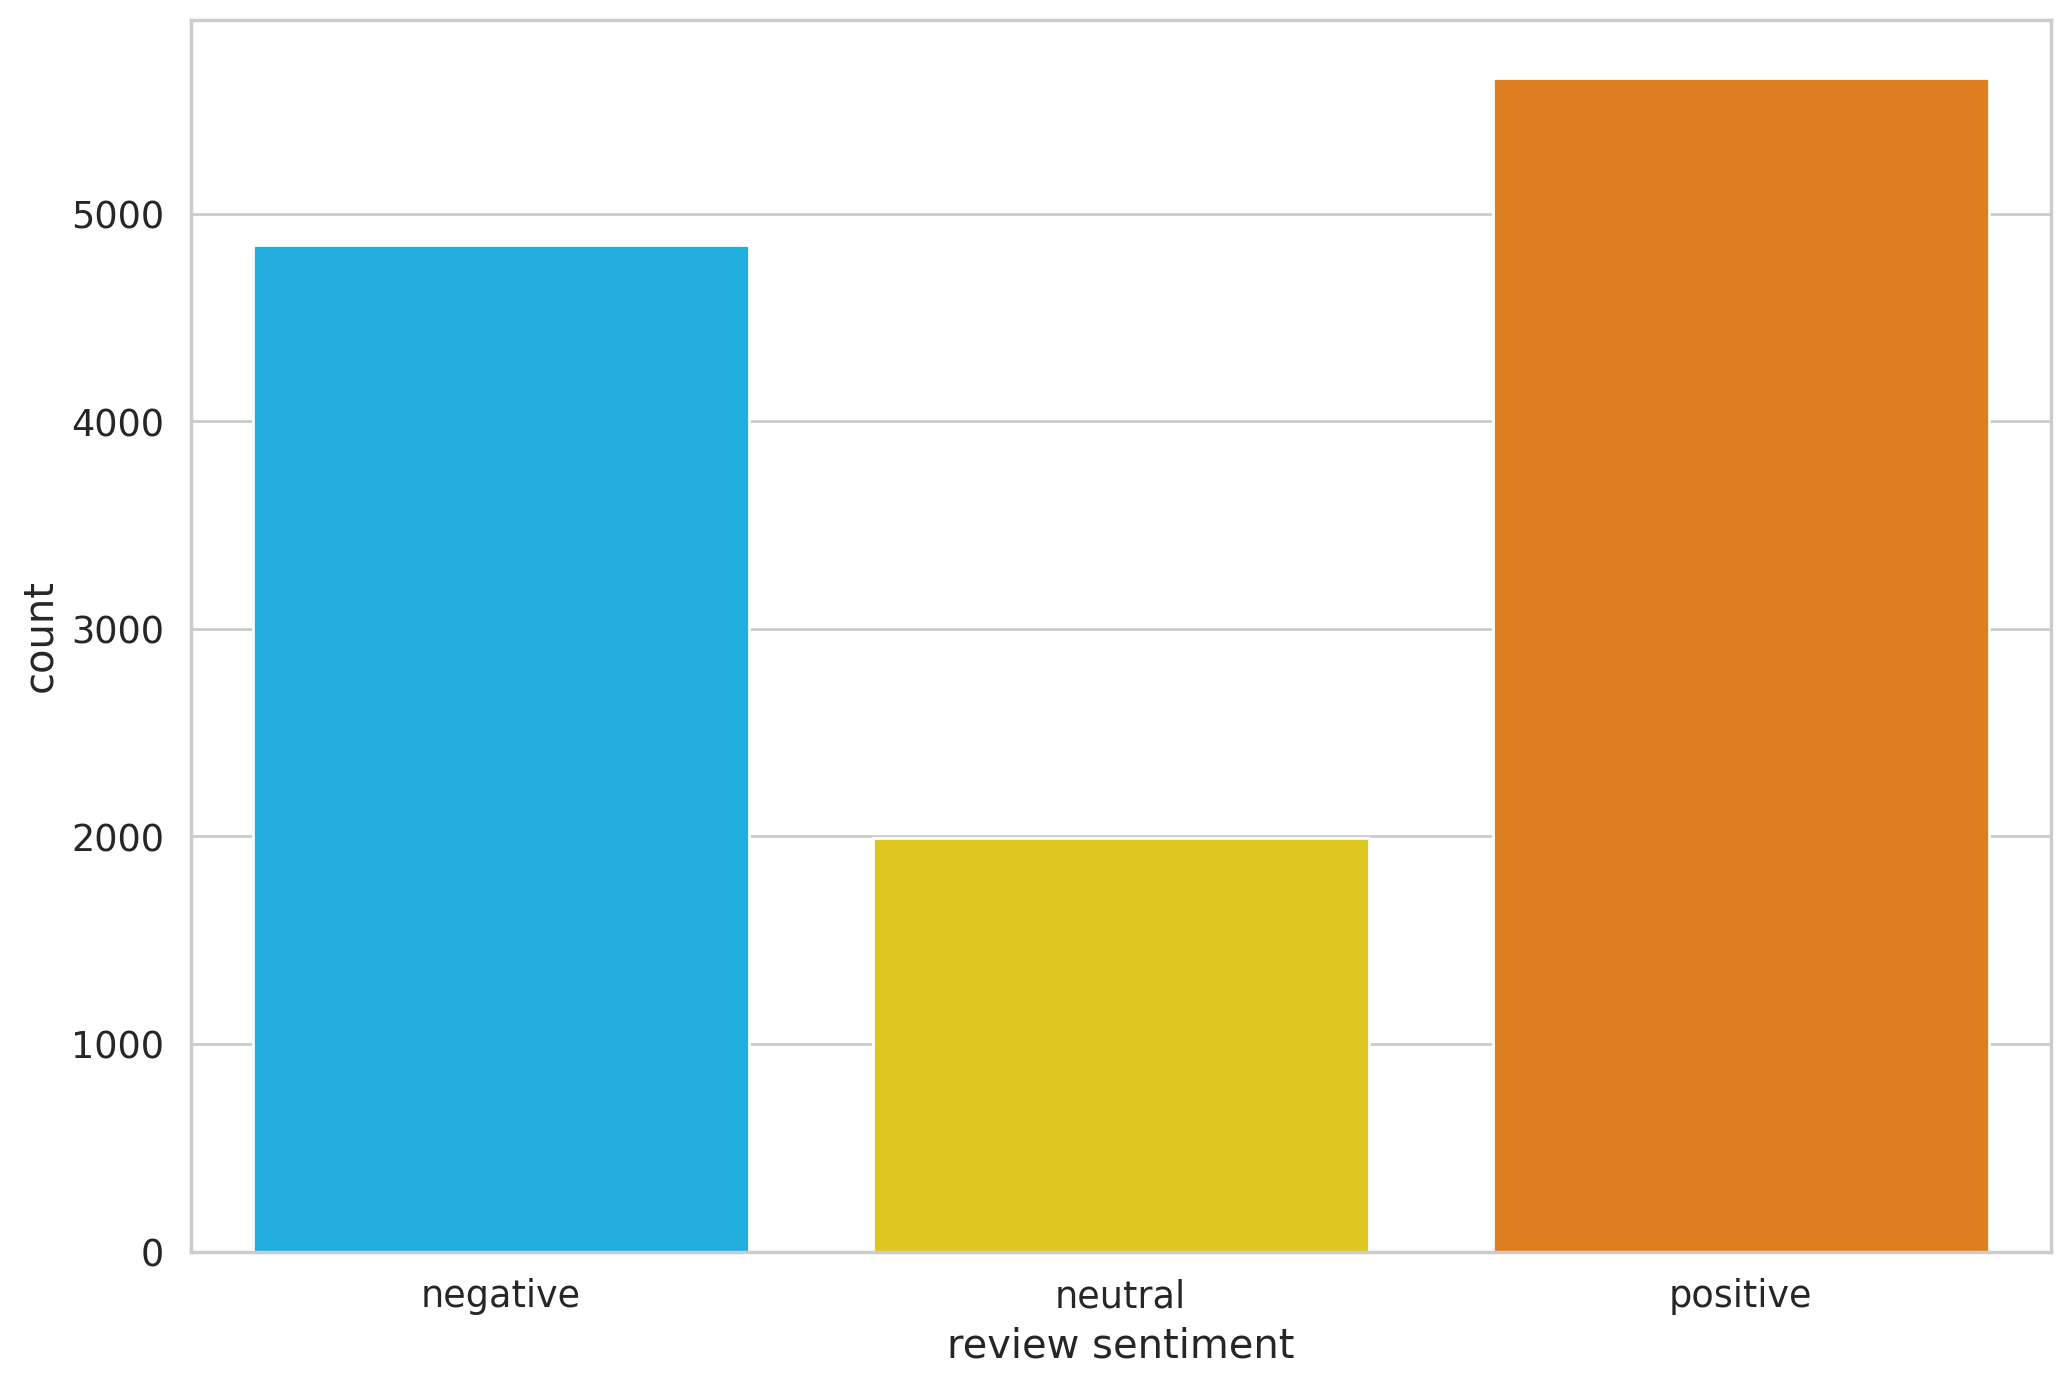

In [173]:
ax = sns.countplot(df, x="sentiment")
plt.xlabel('review sentiment')
ax.set_xticklabels(class_names)

Баланс стал ещё хуже, но продолжаем.

## Шаг 3. Предобработка данных. Токенизация.

Насколько известно, модели машинного обучения не работают с текстом напрямую. Его сначала надо переводить в числовой формат. Для модели BERT нужно много предварительной подготовки. Рекомендации следующие:

- добавить специальные токены, которые будут отделять предложения друг от друга и реализовывать классификацию; 
- сделать все предложения одинаковой длины (использовать padding)
- создать массив из нулей (pad token) и единиц (real token), который будет называться *attention mask*

Библиотека трансформеров предоставляет широкий спектр моделей и готовые методы токенизации.

In [174]:
PRE_TRAINED_MODEL_NAME = 'bert-base-cased'

Загрузим готовую модель [BertTokenizer](https://huggingface.co/transformers/model_doc/bert.html#berttokenizer):

In [175]:
tokenizer = ##WRITE YOUR CODE HERE.from_pretrained(##WRITE YOUR CODE HERE)

Посмотрим на примере, как работает токенизация. Она состоит из двух этапов:
- разделение на токены;
- установление взаимно-однозначного соответствия между токенами и целыми числами.

In [177]:
sample_txt = 'When was I last outside? I am stuck at home for 2 weeks.'

tokens = ##WRITE YOUR CODE HERE
token_ids = tokenizer.convert_tokens_to_ids(##WRITE YOUR CODE HERE)

print(f' Sentence: {##WRITE YOUR CODE HERE}')
print(f'   Tokens: {##WRITE YOUR CODE HERE}')
print(f'Token IDs: {##WRITE YOUR CODE HERE}')

 Sentence: When was I last outside? I am stuck at home for 2 weeks.
   Tokens: ['When', 'was', 'I', 'last', 'outside', '?', 'I', 'am', 'stuck', 'at', 'home', 'for', '2', 'weeks', '.']
Token IDs: [1332, 1108, 146, 1314, 1796, 136, 146, 1821, 5342, 1120, 1313, 1111, 123, 2277, 119]


### Служебные токены

`[SEP]` - обозначение конца предложения.

In [178]:
tokenizer.sep_token, tokenizer.sep_token_id

('[SEP]', 102)

`[CLS]` - если добавить этот токен в начало предложения, то BERT будет понимать, что мы имеем дело с задачей классификации.

In [179]:
tokenizer.cls_token, tokenizer.cls_token_id

('[CLS]', 101)

Также определён специальный токен `[PAD]` для paading.

In [180]:
tokenizer.pad_token, tokenizer.pad_token_id

('[PAD]', 0)

BERT понимает только те токены, которые были в обучающем множестве данных. Всё остальное может быть закодировано при использовании токена `[UNK]` (unknown):

In [181]:
tokenizer.unk_token, tokenizer.unk_token_id

('[UNK]', 100)

Всю работу можно проделать при помощи одного метода [`encode_plus()`](https://huggingface.co/transformers/main_classes/tokenizer.html#transformers.PreTrainedTokenizer.encode_plus):

In [182]:
encoding = tokenizer.encode_plus(
      ##WRITE YOUR CODE HERE,
      max_length=32,
      add_special_tokens=##WRITE YOUR CODE HERE, # Add '[CLS]' and '[SEP]'
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=##WRITE YOUR CODE HERE,
      return_tensors='pt',  # Return PyTorch tensors
    )

encoding.keys()

dict_keys(['input_ids', 'attention_mask'])

Теперь весь набор токенов переведён в формат Tensor и имеет фиксированную длину 32:

In [183]:
print(len(encoding[##WRITE YOUR CODE HERE][0]))
encoding['input_ids'][0]

32


tensor([ 101, 1332, 1108,  146, 1314, 1796,  136,  146, 1821, 5342, 1120, 1313,
        1111,  123, 2277,  119,  102,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Маска внимания (attention mask) имеет ту же размерность:

In [184]:
print(len(encoding[##WRITE YOUR CODE HERE][0]))
encoding['attention_mask']

32


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

Можно произвести обратную операцию и посмотреть на слежубные токены.

In [185]:
tokenizer.##WRITE YOUR CODE HERE(encoding['input_ids'][0])

['[CLS]',
 'When',
 'was',
 'I',
 'last',
 'outside',
 '?',
 'I',
 'am',
 'stuck',
 'at',
 'home',
 'for',
 '2',
 'weeks',
 '.',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

### Выбор длины последовательности.

BERT работает с последовательностями фиксированной длины. Мы воспользуемся самой простой стратегией по выбору максимальной длины - просто соберём все значения в один массив.

In [186]:
token_lens = []

for txt in df.content:
    tokens = tokenizer.encode(##WRITE YOUR CODE HERE, truncation=True)
    token_lens.append(##WRITE YOUR CODE HERE)

И посмотрим на распределение:

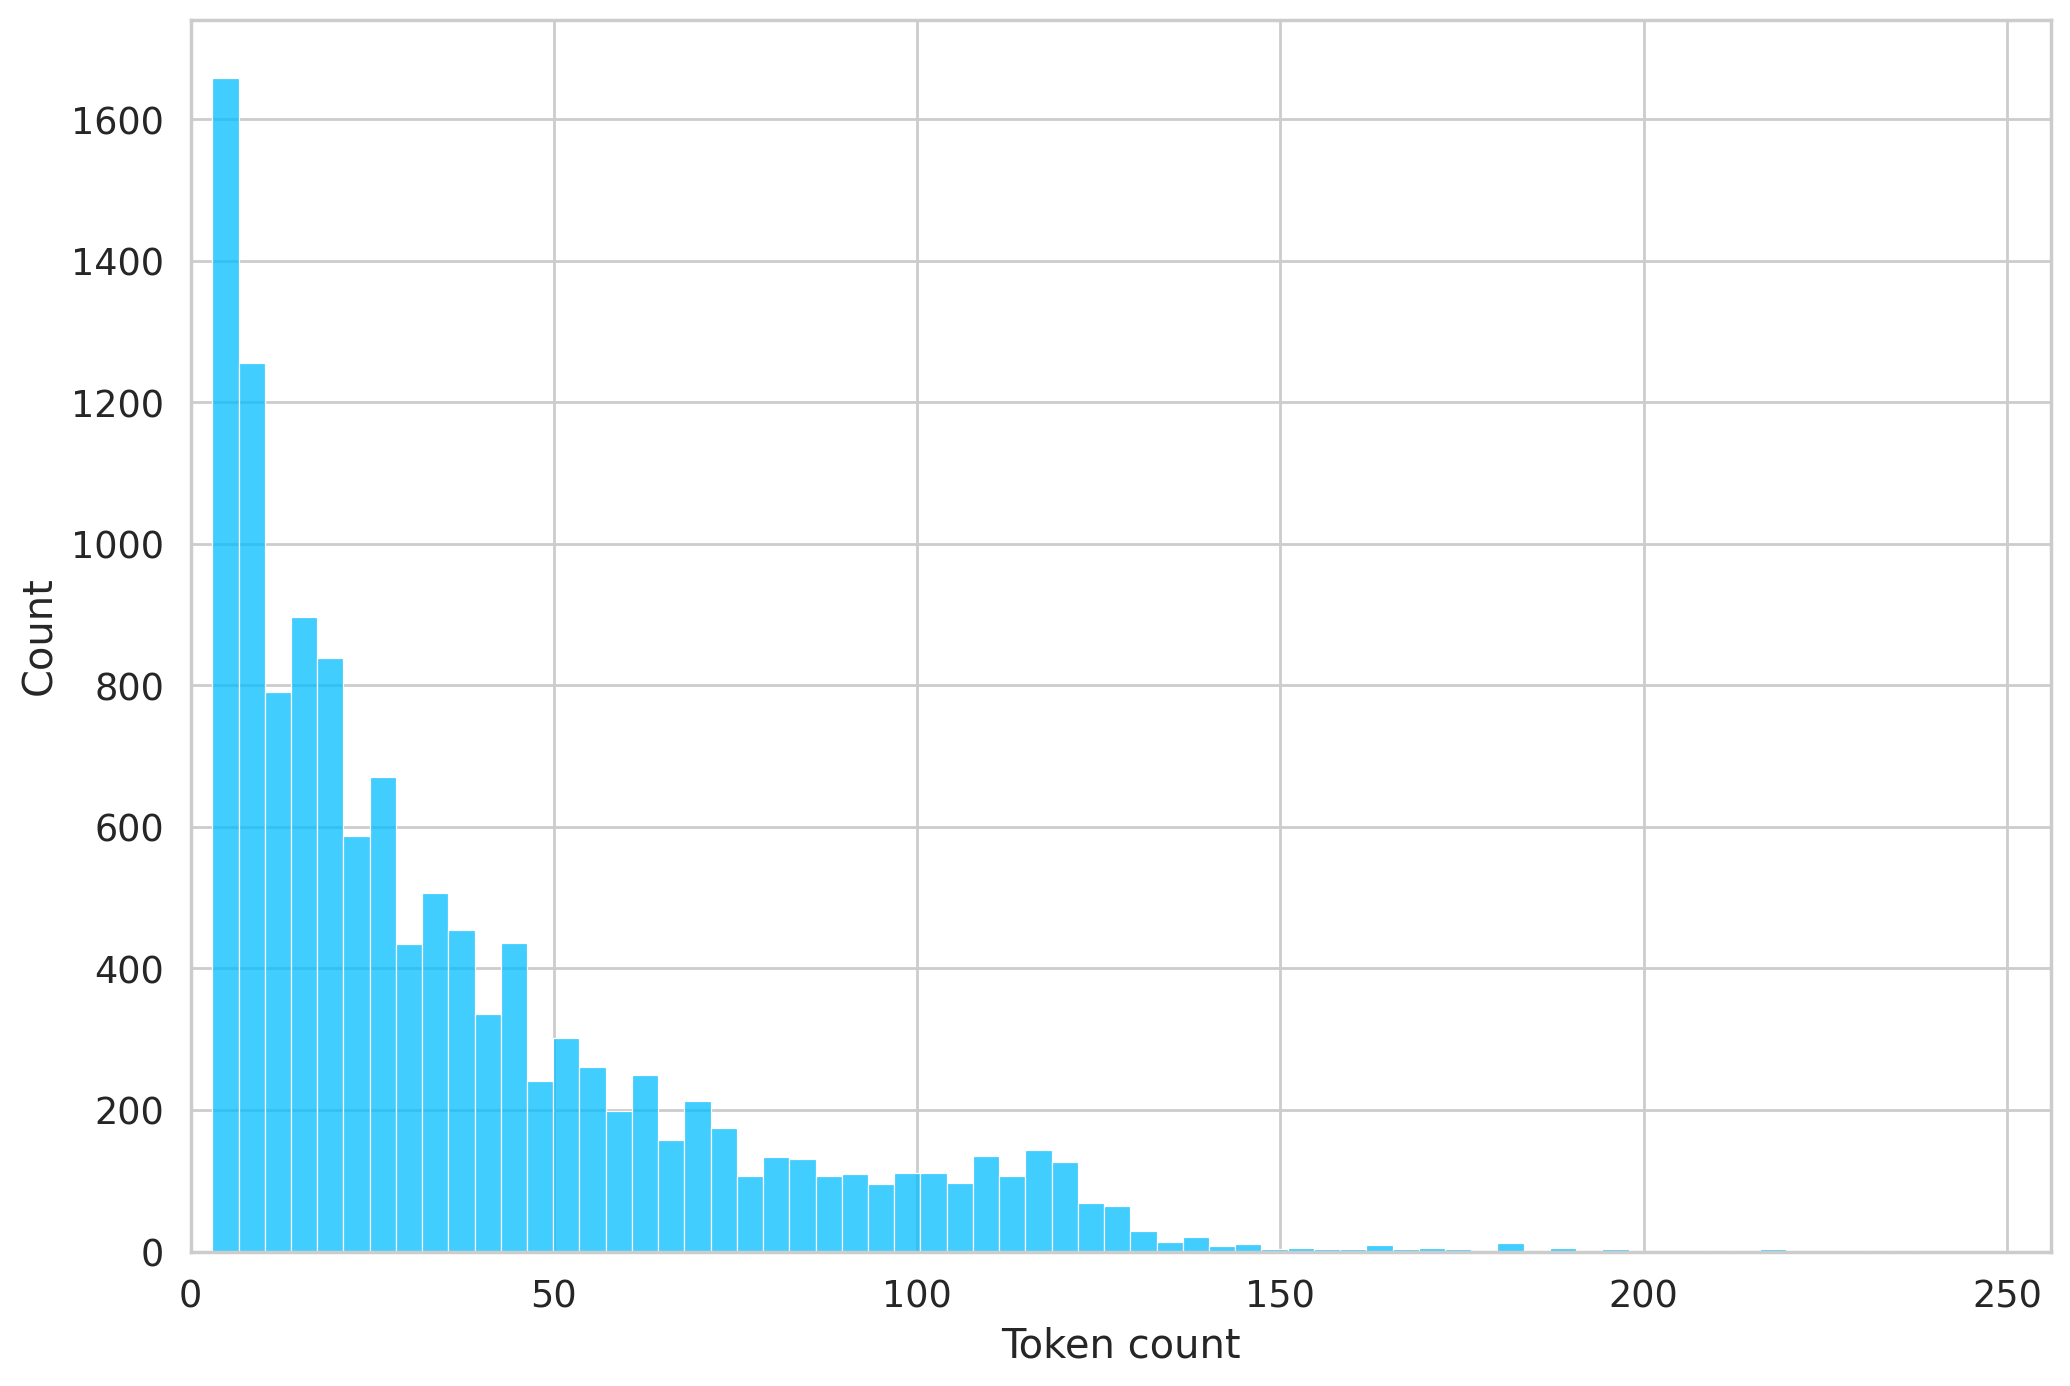

In [187]:
sns.histplot(##WRITE YOUR CODE HERE)
plt.xlim([0, 256]);
plt.xlabel('Token count');

Видно, что большинтво токенов имеют длину менее 160. Напомним, что чем меньше длина, тем быстрее будет работать модель. Необходим баланс между длиной и полнотой информации.

In [235]:
MAX_LEN = ##WRITE YOUR CODE HERE

Создадим класс для набора данных как наследника Dataset:

In [190]:
class GPReviewDataset(##WRITE YOUR CODE HERE):

    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = ##WRITE YOUR CODE HERE
        self.targets = ##WRITE YOUR CODE HERE
        self.tokenizer = ##WRITE YOUR CODE HERE
        self.max_len = ##WRITE YOUR CODE HERE

    def __len__(self):
        return ##WRITE YOUR CODE HERE

    def __getitem__(self, item):
        review = str(##WRITE YOUR CODE HERE)
        target = ##WRITE YOUR CODE HERE

        encoding = tokenizer.encode_plus(
              ##WRITE YOUR CODE HERE,
              max_length=##WRITE YOUR CODE HERE,
              add_special_tokens=##WRITE YOUR CODE HERE, # Добавить '[CLS]' и '[SEP]'
              return_token_type_ids=False,
              padding='max_length',
              truncation=True,
              return_attention_mask=##WRITE YOUR CODE HERE,
              return_tensors='pt',  # Вернуть тензор PyTorch
              )

        return {
          'review_text': review,
          'input_ids': encoding['input_ids'].flatten(),
          'attention_mask': encoding['attention_mask'].flatten(),
          'targets': torch.tensor(target, dtype=torch.long)
        }

Произведём разделение данных на тренировочные, тестовые и проверочные:

In [191]:
df_train, df_test = ##WRITE YOUR CODE HERE(df, test_size=0.1, random_state=##WRITE YOUR CODE HERE)
df_val, df_test = ##WRITE YOUR CODE HERE(df_test, test_size=0.5, random_state=##WRITE YOUR CODE HERE)

In [192]:
df_train.shape, df_val.shape, df_test.shape

((11245, 13), (625, 13), (625, 13))

Создадим функцию для загрузки данных:

In [193]:
def create_data_loader(df, tokenizer, max_len, batch_size):
    ds = GPReviewDataset(
        reviews=df.content.##WRITE YOUR CODE HERE,
        targets=df.sentiment.to_numpy(),
        tokenizer=##WRITE YOUR CODE HERE,
        max_len=##WRITE YOUR CODE HERE
        )

    return DataLoader(
        ##WRITE YOUR CODE HERE,
        batch_size=##WRITE YOUR CODE HERE,
        num_workers=2
        )

Выберем размер батча и загрузим данные при помощи построенной функции:

In [194]:
BATCH_SIZE = ##WRITE YOUR CODE HERE

train_data_loader = ##WRITE YOUR CODE HERE(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = ##WRITE YOUR CODE HERE(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = ##WRITE YOUR CODE HERE(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

Посмотрим на один из полученных батчей:

In [195]:
data = next(iter(##WRITE YOUR CODE HERE))
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [196]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([16, 200])
torch.Size([16, 200])
torch.Size([16])


## Шаг 4. Загрузка модели BERT из Hugging Face

В готовых бибилиотеках реализованы множество готовых типов: [BertForSequenceClassification](https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification), [BertForQuestionAnswering](https://huggingface.co/transformers/model_doc/bert.html#bertforquestionanswering) и другие.

В этом задании мы будем использовать базовую модель [BertModel](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) и самостоятельно построим классификатор. 

Сначала загрузим саму модель:

In [13]:
bert_model = ##WRITE YOUR CODE HERE.from_pretrained(##WRITE YOUR CODE HERE, return_dict=False)

NameError: name 'PRE_TRAINED_MODEL_NAME' is not defined

И попробуем использовать её для кодирования предложенного теста:

In [198]:
last_hidden_state, pooled_output = bert_model(
  input_ids=##WRITE YOUR CODE HERE['input_ids'],
  attention_mask=##WRITE YOUR CODE HERE['attention_mask'],
  return_dict=False
)

In [199]:
type(pooled_output)

torch.Tensor

In [200]:
last_hidden_state

tensor([[[ 0.4070,  0.1858, -0.2489,  ..., -0.0298,  0.1574, -0.0787],
         [ 0.2521, -0.4902,  0.4746,  ..., -0.3883,  0.2401, -0.1347],
         [ 0.0866, -0.0274, -0.5215,  ...,  0.6011, -0.2430,  0.6801],
         ...,
         [ 0.0907,  0.1219, -0.3152,  ...,  0.0500,  0.0258,  0.2034],
         [ 0.0084,  0.2015,  0.0708,  ..., -0.0751,  0.2075, -0.0857],
         [ 0.0273,  0.2316,  0.1510,  ..., -0.1111,  0.0845, -0.1100]]],
       grad_fn=<NativeLayerNormBackward0>)

Мы знаем, что `last_hidden_state` - это последовательность скрытых состояний поледнего слоя модели. Итоговый выход `pooled_output` является применением [BertPooler](https://github.com/huggingface/transformers/blob/edf0582c0be87b60f94f41c659ea779876efc7be/src/transformers/modeling_bert.py#L426) к `last_hidden_state`:

In [201]:
last_hidden_state.shape

torch.Size([1, 32, 768])

У нас есть скрытые состояния для 32 токенов (длина последовательности примеров). Но почему 768? Это количество нейронов на скрытом слое для полносвязной нейронной сети. Проверим это:

In [202]:
bert_model.config.hidden_size

768

Можно воспринимать `pooled_output` как итоговый выводы, которые сделал BERT. Посмотрим на выходное состояние:

In [203]:
pooled_output.shape

torch.Size([1, 768])

Мы можем использовать эти знания, чтобы создать классификатор на основе BERT:

In [204]:
class SentimentClassifier(##WRITE YOUR CODE HERE):

    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = ##WRITE YOUR CODE HERE.from_pretrained(##WRITE YOUR CODE HERE, return_dict=False)
        self.drop = ##WRITE YOUR CODE HERE(p=0.3)
        self.out = ##WRITE YOUR CODE HERE

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(
          input_ids=##WRITE YOUR CODE HERE,
          attention_mask=##WRITE YOUR CODE HERE
        )
        output = self.drop(##WRITE YOUR CODE HERE)
        return ##WRITE YOUR CODE HERE

Мы используем слой dropout для регуляризации и полносвязный слой для выходных значений. Обращаем внимание, что мы будем возвращать необработанное выходное значение, так как оно необходимо для передачи в функцию потерь кросс-энтропию. 

Это должно работать как и любая другая модель на PyTorch model. Создадаим экземпляр класса и перемести его на GPU:

In [205]:
model = ##WRITE YOUR CODE HERE(len(class_names))
model = model.to(##WRITE YOUR CODE HERE)

Перенесём пример батча из тренировочных данных на GPU:

In [206]:
input_ids = ##WRITE YOUR CODE HERE.to(device)
attention_mask = ##WRITE YOUR CODE HERE.to(device)

print(input_ids.shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([16, 200])
torch.Size([16, 200])


Чтобы получить вероятности предсказаний, необходимо применить функцию softmax к выходу моделей:

In [207]:
##WRITE YOUR CODE HERE(model(input_ids, attention_mask), dim=1)

tensor([[0.2436, 0.4429, 0.3134],
        [0.2343, 0.3055, 0.4602],
        [0.3186, 0.2772, 0.4043],
        [0.2116, 0.3883, 0.4001],
        [0.5837, 0.2058, 0.2104],
        [0.2549, 0.3533, 0.3918],
        [0.2507, 0.3553, 0.3940],
        [0.3946, 0.2217, 0.3837],
        [0.3583, 0.1887, 0.4531],
        [0.3503, 0.1905, 0.4592],
        [0.3067, 0.2542, 0.4391],
        [0.3532, 0.1884, 0.4583],
        [0.2181, 0.3887, 0.3932],
        [0.2915, 0.2935, 0.4150],
        [0.3718, 0.2572, 0.3710],
        [0.1536, 0.3150, 0.5314]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

## Шаг 5. Тренировка модели

Для обучения модели будем использовать готовый оптимизатор [AdamW](https://huggingface.co/transformers/main_classes/optimizer_schedules.html#adamw) из библиотеки Hugging Face.

Обращаем внимание на функцию get_linear_schedule_with_warmup, которая плавно увеличивает скорость обучения за счёт увеличения шага обучения от нуля до заданного значения lr.

In [208]:
EPOCHS = 1

optimizer = ##WRITE YOUR CODE HERE(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  ##WRITE YOUR CODE HERE,
  num_warmup_steps=0,
  num_training_steps=##WRITE YOUR CODE HERE
)

loss_fn = nn.CrossEntropyLoss().to(device)

Авторы модели BERT рекомендуют следующие значения гиперпараметров:

- Batch size: 16, 32
- Learning rate (Adam): 5e-5, 3e-5, 2e-5
- Number of epochs: 2, 3, 4

Обращаем внимание, что увеличение размера батча уменьшает время работы, но ухудшает точность.

Напишем функцию обучения в рамках одной эпохи:

In [209]:
def train_epoch(
      model,
      data_loader,
      loss_fn,
      optimizer,
      device,
      scheduler,
      n_examples
      ):
    model = ##WRITE YOUR CODE HERE

    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = ##WRITE YOUR CODE HERE.to(device)
        attention_mask = ##WRITE YOUR CODE HERE.to(device)
        targets = ##WRITE YOUR CODE HERE.to(device)

        outputs = model(
          input_ids=##WRITE YOUR CODE HERE,
          attention_mask=##WRITE YOUR CODE HERE
        )

        _, preds = ##WRITE YOUR CODE HERE(outputs, dim=1)
        loss = ##WRITE YOUR CODE HERE

        correct_predictions += torch.sum(##WRITE YOUR CODE HERE)
        losses.append(##WRITE YOUR CODE HERE)

        ##WRITE YOUR CODE HERE
        nn.utils.##WRITE YOUR CODE HERE(model.parameters(), max_norm=1.0)
        ##WRITE YOUR CODE HERE
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

Два нововведения:
- планировщик(scheduler) вызывается каждый раз, когда батч попадает в модель;
- взрыв градиента осуществляется при помощи функции обрезки по заданному значению [clip_grad_norm_](https://pytorch.org/docs/stable/nn.html#clip-grad-norm).

Напишем функцию для оценки модели:

In [210]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = ##WRITE YOUR CODE HERE

    losses = []
    correct_predictions = 0

    ##WRITE YOUR CODE HERE
        for d in data_loader:
            input_ids = ##WRITE YOUR CODE HERE.to(device)
            attention_mask = d##WRITE YOUR CODE HERE.to(device)
            targets = ##WRITE YOUR CODE HERE.to(device)

            outputs = model(
            input_ids=##WRITE YOUR CODE HERE,
            attention_mask=a##WRITE YOUR CODE HERE
            )
            _, preds = ##WRITE YOUR CODE HERE(outputs, dim=1)

            loss = ##WRITE YOUR CODE HERE

            correct_predictions += torch.sum(##WRITE YOUR CODE HERE)
            losses.append(##WRITE YOUR CODE HERE)

    return correct_predictions.double() / n_examples, np.mean(losses)

Теперь реализуем троенировочный цикл, где будем так же сохранять историю по значению потерь и точности:

In [211]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    train_acc, train_loss = train_epoch(
        ##WRITE YOUR CODE HERE,
        train_data_loader,
        ##WRITE YOUR CODE HERE,
        optimizer,
        device,
        scheduler,
        len(df_train)
        )

    print(f'Train loss {train_loss} accuracy {train_acc}')

    val_acc, val_loss = eval_model(
        ##WRITE YOUR CODE HERE,
        val_data_loader,
        ##WRITE YOUR CODE HERE,
        device,
        len(df_val)
        )

    print(f'Val   loss {val_loss} accuracy {val_acc}')
    print()

    history['train_acc'].append(##WRITE YOUR CODE HERE)
    history['train_loss'].append(##WRITE YOUR CODE HERE)
    history['val_acc'].append(##WRITE YOUR CODE HERE)
    history['val_loss'].append(##WRITE YOUR CODE HERE)



    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

Epoch 1/10
----------
Train loss 0.6878170227767054 accuracy 0.7283236994219654
Val   loss 0.6093910835683346 accuracy 0.7728

Epoch 2/10
----------
Train loss 0.5305519671752985 accuracy 0.7920853712761228
Val   loss 0.6551918532699347 accuracy 0.7616

Epoch 3/10
----------
Train loss 0.405833662997608 accuracy 0.8505113383726101
Val   loss 0.7911782532930374 accuracy 0.7536

Epoch 4/10
----------


KeyboardInterrupt: ignored

Выведем графически результаты на экран, для этого сначала реализуем функцию для перевода данных в обычный массив из defaultdict:

In [219]:
def fix_arr(arr):
    res = []
    for i in range(len(arr)):
        res.append(##WRITE YOUR CODE HERE)

    return res

history['train_acc'] = ##WRITE YOUR CODE HERE(history['train_acc'])
history['val_acc'] = ##WRITE YOUR CODE HERE(history['val_acc'])

AttributeError: ignored

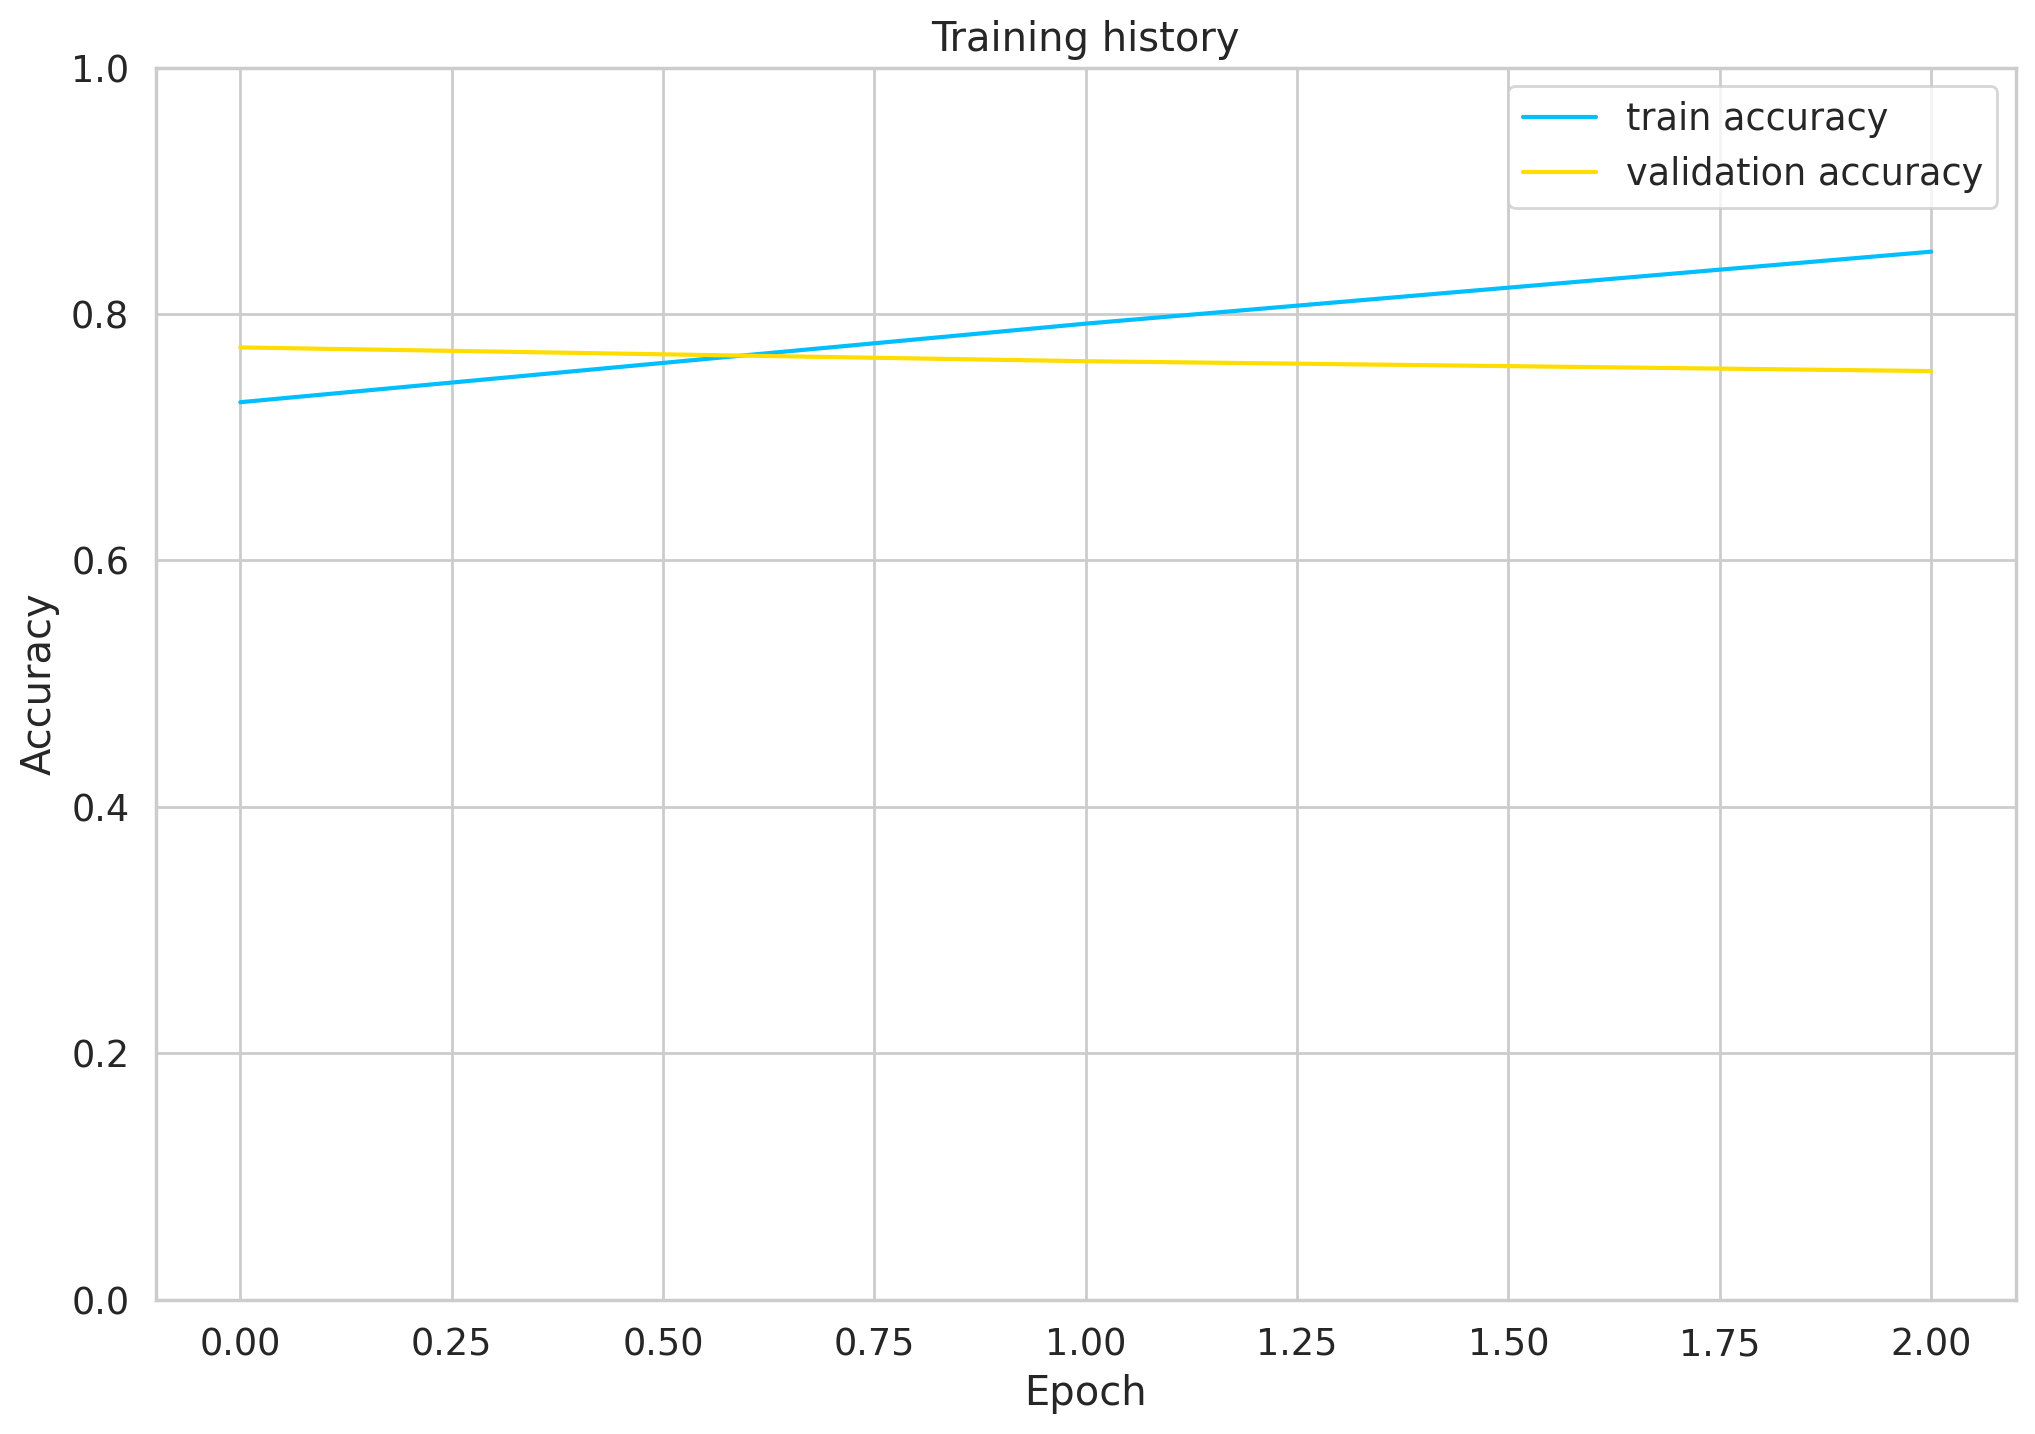

In [220]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

У авторов модель достигает 100% точности после 10 эпох. Можете поэкспериментировать и менять гиперпараметры модели. Либо, если не хотите ждать, загрузить уже готовую модель:

In [ ]:
# !gdown --id 1V8itWtowCYnb2Bc9KlK9SxGff9WwmogA

# model = SentimentClassifier(len(class_names))
# model.load_state_dict(torch.load('best_model_state.bin'))
# model = model.to(device)

## Шаг 6. Анализ полученных результатов

Сначала посчитаем точность на тестовых данных:

In [221]:
test_acc, _ = eval_model(
    ##WRITE YOUR CODE HERE,
    test_data_loader,
    ##WRITE YOUR CODE HERE,
    device,
    len(df_test)
    )

test_acc.item()

0.6832

Построим функцию для получения предсказаний модели:

In [222]:
def get_predictions(model, data_loader):
    model = model.eval()

    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:

            texts = d["review_text"]
            input_ids = ##WRITE YOUR CODE HERE.to(device)
            attention_mask = ##WRITE YOUR CODE HERE.to(device)
            targets = ##WRITE YOUR CODE HERE.to(device)

            outputs = model(
            input_ids=i##WRITE YOUR CODE HERE,
            attention_mask=##WRITE YOUR CODE HERE
            )
            _, preds = ##WRITE YOUR CODE HERE(outputs, dim=1)

            probs = ##WRITE YOUR CODE HERE(outputs, dim=1)

            review_texts.extend(##WRITE YOUR CODE HERE)
            predictions.extend(##WRITE YOUR CODE HERE)
            prediction_probs.extend(##WRITE YOUR CODE HERE)
            real_values.extend(##WRITE YOUR CODE HERE)

    predictions = torch.stack(##WRITE YOUR CODE HERE).cpu()
    prediction_probs = torch.stack(##WRITE YOUR CODE HERE).cpu()
    real_values = torch.stack(##WRITE YOUR CODE HERE).cpu()
    return review_texts, predictions, prediction_probs, real_values

Она похожа на функцию оценки модели, за исключением того, что мы сохраняем текст отзывов и предсказанную вероятность, полученную путём применения softmax к выходам модели:

In [223]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    ##WRITE YOUR CODE HERE,
    ##WRITE YOUR CODE HERE
    )

Выведем classification report:

In [224]:
print(##WRITE YOUR CODE HERE(##WRITE YOUR CODE HERE, zero_division=0))

              precision    recall  f1-score   support

    negative       0.84      0.65      0.74       242
     neutral       0.33      0.18      0.24       125
    positive       0.67      0.95      0.78       258

    accuracy                           0.68       625
   macro avg       0.61      0.60      0.59       625
weighted avg       0.67      0.68      0.66       625



Построим матрицу ошибок:

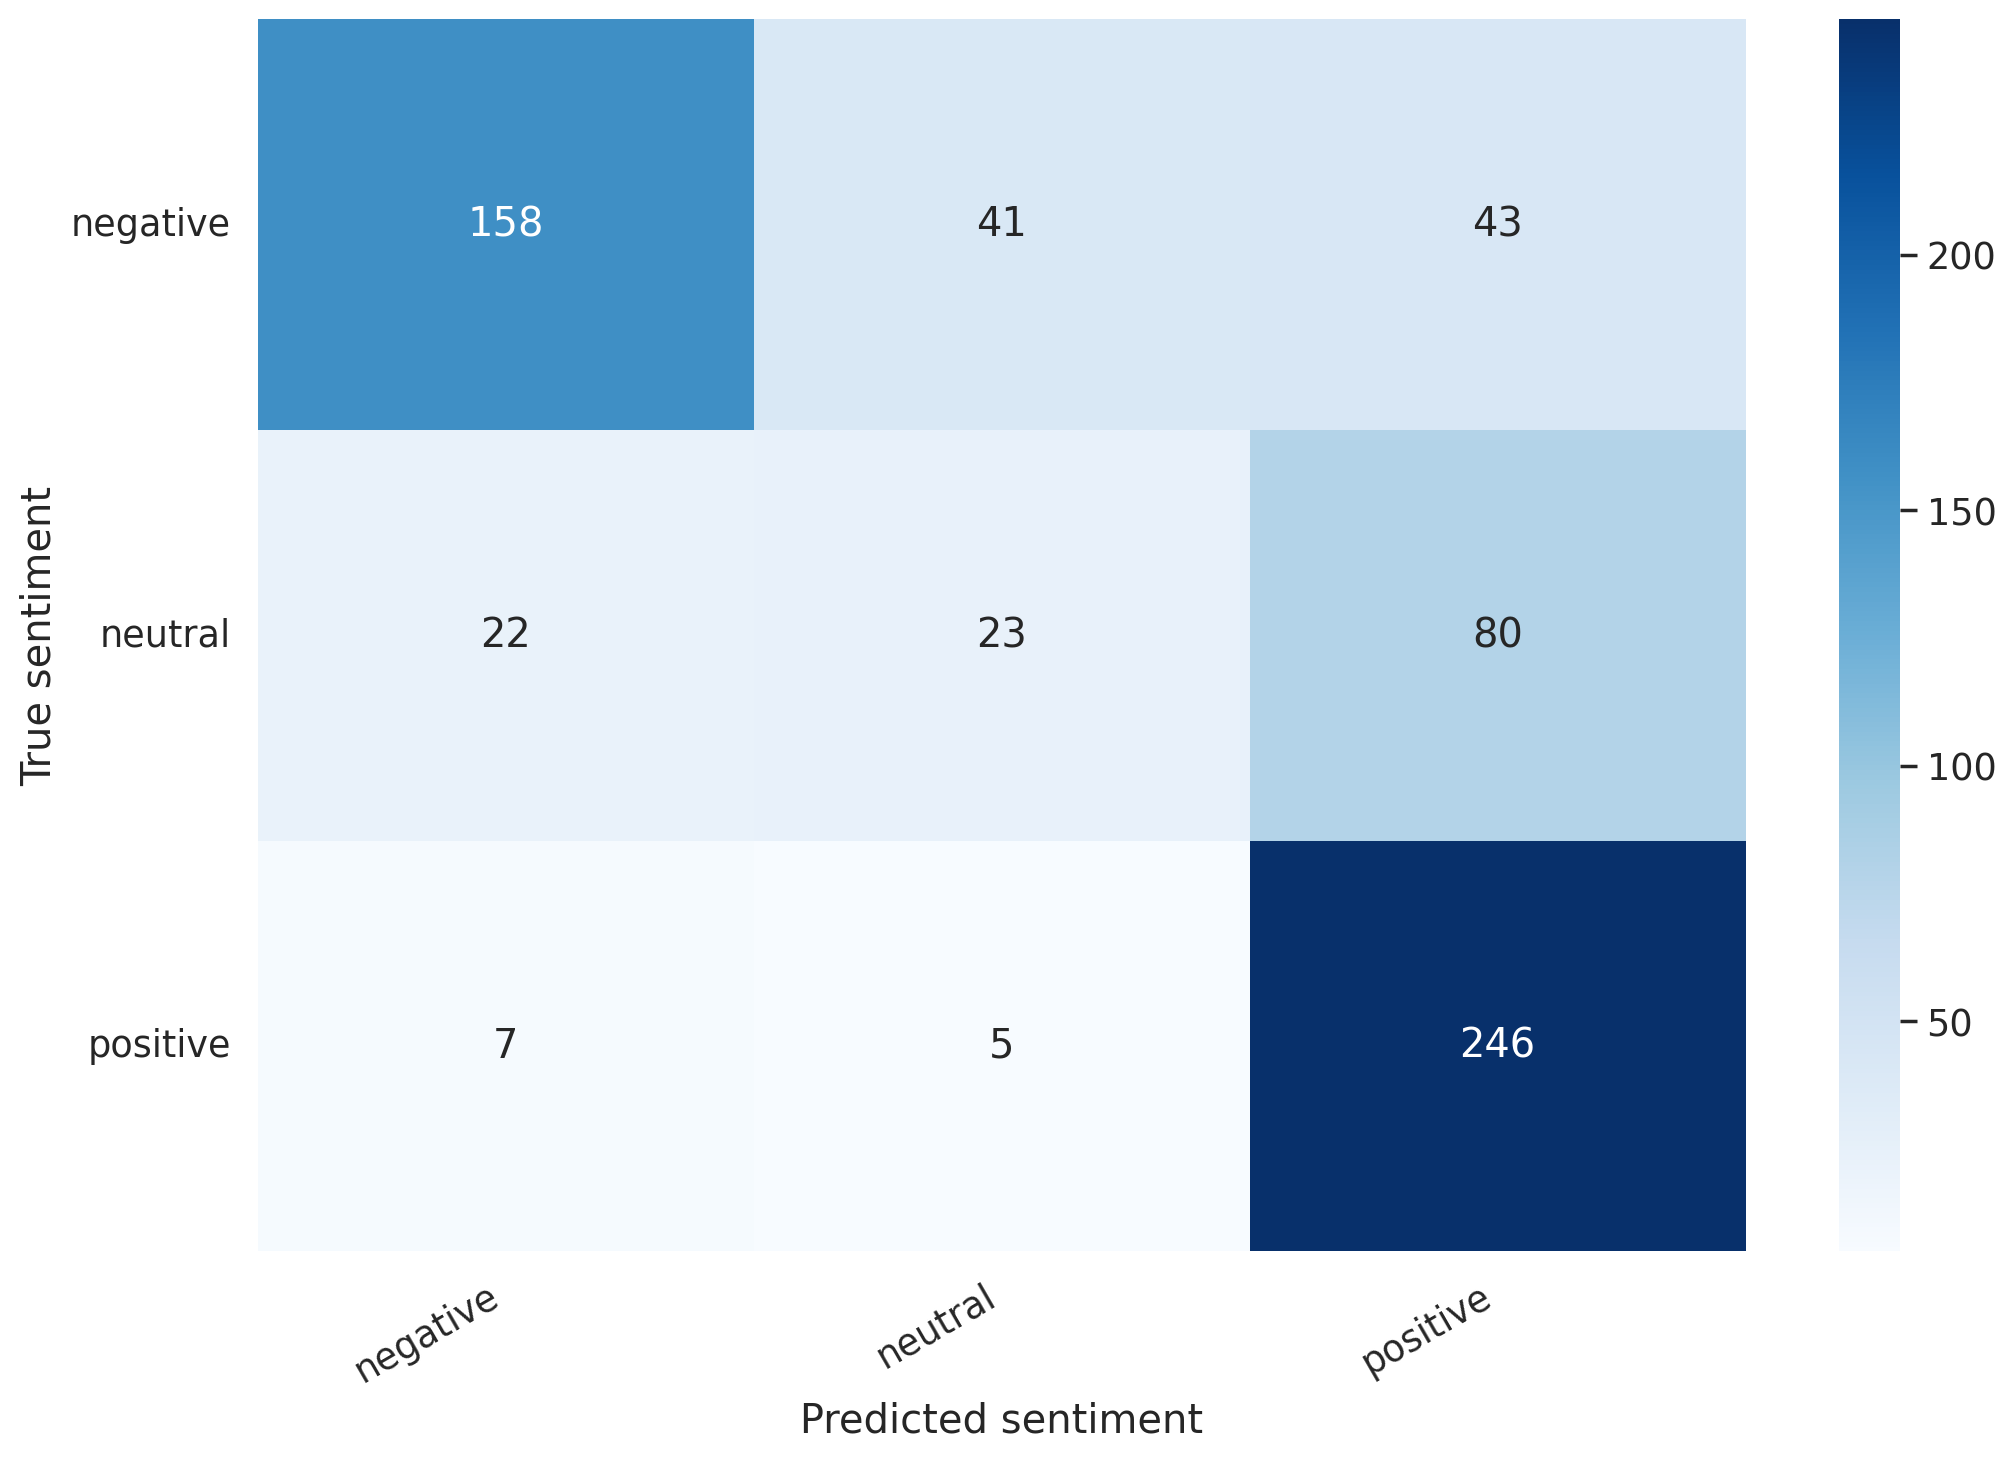

In [225]:
def show_confusion_matrix(##WRITE YOUR CODE HERE):
    hmap = sns.heatmap(##WRITE YOUR CODE HERE, annot=True, fmt="d", cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('True sentiment')
    plt.xlabel('Predicted sentiment')

cm = confusion_matrix(##WRITE YOUR CODE HERE)
df_cm = pd.DataFrame(##WRITE YOUR CODE HERE, index=class_names, columns=class_names)
show_confusion_matrix(##WRITE YOUR CODE HERE)

Как мы видим, хуже всего модель различает нейтральные отзывы.

Посмотрим, как она обработает конкретные примеры:

In [226]:
idx = 2

review_text = ##WRITE YOUR CODE HERE
true_sentiment = ##WRITE YOUR CODE HERE
pred_df = pd.DataFrame({
    'class_names': ##WRITE YOUR CODE HERE,
    'values': ##WRITE YOUR CODE HERE[idx]
})

In [227]:
print("\n".join(wrap(review_text)))
print()
print(f'True sentiment: {##WRITE YOUR CODE HERE}')

Suddenly not displaying all other calendars. And after reinstalling,
app won't open.

True sentiment: negative


На графике:

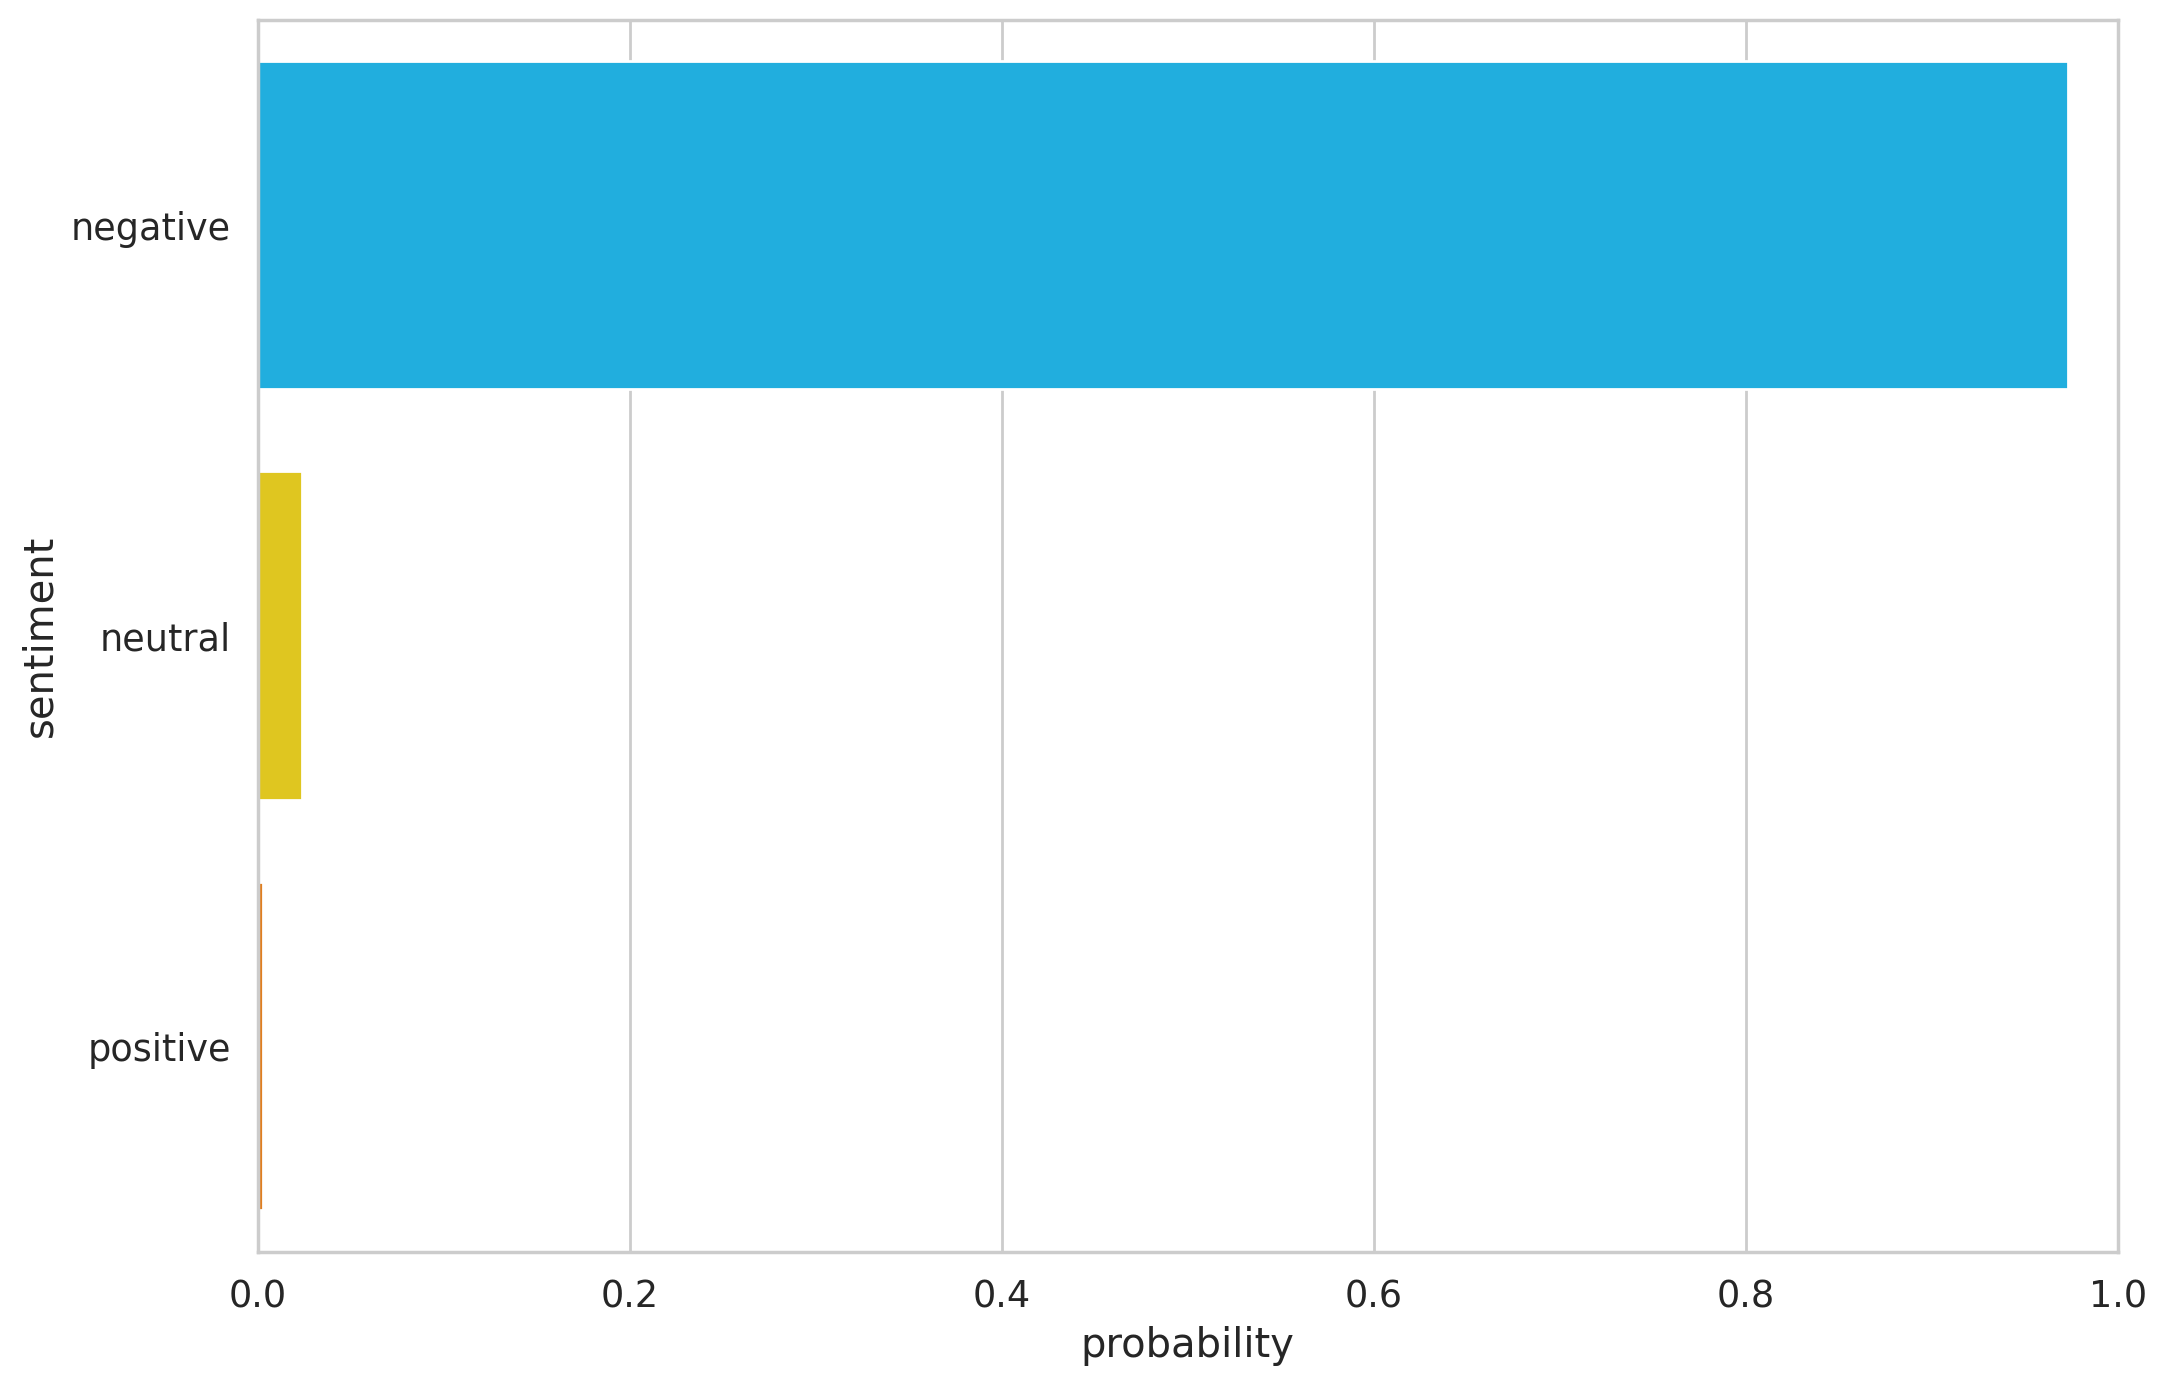

In [228]:
sns.barplot(x='values', y='class_names', data=pred_df, orient='h')
plt.ylabel('sentiment')
plt.xlabel('probability')
plt.xlim([0, 1]);

### Предсказания на новых примерах 

Испробуем нашу модель на своих примерах:

In [232]:
review_text = "I like completing my todos! Best app ever!!!"
#review_text = 'It was a terrible movie, everything is bad'

Для начала необходимо использовать tokenizer, чтобы закодировать текст:

In [233]:
encoded_review = ##WRITE YOUR CODE HERE(
    ##WRITE YOUR CODE HERE,
    max_length=512,
    add_special_tokens=True,
    return_token_type_ids=False,
    padding='longest',
    return_attention_mask=True,
    return_tensors='pt',
    )

А теперь перейдём к предсказаниям:

In [234]:
input_ids = ##WRITE YOUR CODE HERE.to(device)
attention_mask = ##WRITE YOUR CODE HERE.to(device)

output = ##WRITE YOUR CODE HERE
_, prediction = ##WRITE YOUR CODE HERE

print(f'Review text: {##WRITE YOUR CODE HERE}')
print(f'Sentiment  : {##WRITE YOUR CODE HERE}')

Review text: I like completing my todos! Best app ever!!!
Sentiment  : positive


## Полезные ссылки:

- [Read the tutorial](https://www.curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/)
- [Run the notebook in your browser (Google Colab)](https://colab.research.google.com/drive/1PHv-IRLPCtv7oTcIGbsgZHqrB5LPvB7S)
- [Read the `Getting Things Done with Pytorch` book](https://github.com/curiousily/Getting-Things-Done-with-Pytorch)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [L11 Language Models - Alec Radford (OpenAI)](https://www.youtube.com/watch?v=BnpB3GrpsfM)
- [The Illustrated BERT, ELMo, and co.](https://jalammar.github.io/illustrated-bert/)
- [BERT Fine-Tuning Tutorial with PyTorch](https://mccormickml.com/2019/07/22/BERT-fine-tuning/)
- [How to Fine-Tune BERT for Text Classification?](https://arxiv.org/pdf/1905.05583.pdf)
- [Huggingface Transformers](https://huggingface.co/transformers/)
- [BERT Explained: State of the art language model for NLP](https://towardsdatascience.com/bert-explained-state-of-the-art-language-model-for-nlp-f8b21a9b6270)